In [12]:
!pip install gdown pandas numpy scipy

In [33]:
gid_map = {
    'optimality': '36197349'
}

sheet_id = "1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ"

In [34]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats
import os
from datetime import datetime


def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

import pandas as pd
import numpy as np
from scipy import stats

def calculate_grouped_stats_and_ci(df: pd.DataFrame, 
                                   grouping_columns: list, 
                                   value_columns: list,  # Changed to a list
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for multiple given value columns.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_columns (list): A list of column names for which to calculate the mean,
                              count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns for each value column.
    """
    
    # Check if all value_columns are numeric
    for col in value_columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"The '{col}' in value_columns must be a numeric column.")

    # Create an aggregation dictionary for multiple value columns
    agg_dict = {col: ['mean', 'count', 'std'] for col in value_columns}
    
    # Group by the specified columns and aggregate
    grouped_df = df.groupby(grouping_columns).agg(agg_dict).reset_index()

    # Flatten MultiIndex columns and rename for clarity
    new_columns = []
    for col_pair in grouped_df.columns:
        if col_pair[1]: # If it's a multi-level column (e.g., ('Value', 'mean'))
            new_columns.append(f"{col_pair[0]}_{col_pair[1]}")
        else: # If it's a grouping column
            new_columns.append(col_pair[0])
    grouped_df.columns = new_columns

    # Rename suffixes for consistency
    rename_map = {}
    for col in value_columns:
        rename_map[f'{col}_mean'] = f'{col}_Average'
        rename_map[f'{col}_count'] = f'{col}_Count'
        rename_map[f'{col}_std'] = f'{col}_Std_Dev'
    grouped_df.rename(columns=rename_map, inplace=True)

    # Function to calculate confidence interval for a single row and a specific value column
    def calculate_ci_for_column_in_row(row, col_prefix, conf_level):
        avg = row.get(f'{col_prefix}_Average')
        count = row.get(f'{col_prefix}_Count')
        std_dev = row.get(f'{col_prefix}_Std_Dev')

        # Check for NaN values or insufficient data
        if pd.isna(avg) or pd.isna(count) or pd.isna(std_dev) or count < 2:
            return np.nan, np.nan
        
        # Degrees of freedom for t-distribution
        df_t = count - 1
        
        # Calculate standard error of the mean
        sem = std_dev / np.sqrt(count)
        
        # Calculate confidence interval
        lower, upper = stats.t.interval(conf_level, df_t, loc=avg, scale=sem)
        return lower, upper

    # Apply the confidence interval calculation for each value column
    for col in value_columns:
        grouped_df[[f'{col}_CI_Lower', f'{col}_CI_Upper']] = grouped_df.apply(
            lambda row: calculate_ci_for_column_in_row(row, col, confidence_level),
            axis=1,
            result_type='expand'
        )
    
    return grouped_df

In [35]:
optimality_df = get_pandas_from_gid('optimality')
optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] = optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] / 3
optimality_df

/home/diogoocv/miniconda3/lib/python3.13/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=36197349
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/optimality.csv
7.11MB [00:00, 9.96MB/s]


,graph_name,metaheuristic,initial_vertices,num_initial_solutions,timeout_ms,objective_function,num_threads,repetition,total_time_ms,time_to_best_solution_ms,effective_runs,cost_best_solution,vertices_best_solution,edges_best_solution,best_solution
0,dblp,ts2,10,10000,3000,triangledensestsubgraph,32,1,873813,873000,9270,13585.000000,287,41041,26/02/04 16:45:57 SubgraphOptimizationApp$ Ela...
1,dblp,ts2,10,10000,3000,triangledensestsubgraph,32,3,873926,873000,9270,13020.000000,281,39340,26/02/04 17:15:18 SubgraphOptimizationApp$ Ela...
2,dblp,ts2,10,10000,3000,triangledensestsubgraph,32,2,873775,871000,9270,12376.000000,274,37401,26/02/04 17:00:38 SubgraphOptimizationApp$ Ela...
3,dblp,ts1,10,10000,3000,triangledensestsubgraph,32,2,873828,871000,9270,11748.333333,267,35511,26/01/31 21:31:42 SubgraphOptimizationApp$ Ela...
4,dblp,ts1,10,10000,3000,triangledensestsubgraph,32,1,873877,871000,9270,11660.000000,266,35245,26/01/31 21:17:02 SubgraphOptimizationApp$ Ela...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855,dblp,ils,10,100,2000,conductance,32,2,6479,4000,90,0.534247,189,507,"vsub(nvertices=189,nedges=507,vertices={164877..."
4856,dblp,ils,10,100,2000,conductance,32,4,6434,2000,90,0.533724,200,546,"vsub(nvertices=200,nedges=546,vertices={532530..."
4857,dblp,ils,10,100,3000,conductance,32,2,9514,5000,90,0.520039,198,532,"vsub(nvertices=198,nedges=532,vertices={124387..."
4858,dblp,ils,10,100,3000,conductance,32,1,9492,9000,90,0.519510,268,679,"vsub(nvertices=268,nedges=679,vertices={217441..."


In [36]:
grouping_columns = ["metaheuristic", "graph_name", "objective_function", "initial_vertices", "num_initial_solutions", "timeout_ms", "num_threads"]
value_column = ["cost_best_solution", "total_time_ms"]
grouped_df = calculate_grouped_stats_and_ci(optimality_df, grouping_columns, value_column)
grouped_df

/home/diogoocv/miniconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/diogoocv/miniconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,metaheuristic,graph_name,objective_function,initial_vertices,num_initial_solutions,timeout_ms,num_threads,cost_best_solution_Average,cost_best_solution_Count,cost_best_solution_Std_Dev,total_time_ms_Average,total_time_ms_Count,total_time_ms_Std_Dev,cost_best_solution_CI_Lower,cost_best_solution_CI_Upper,total_time_ms_CI_Lower,total_time_ms_CI_Upper
0,ils,amazon,conductance,10,100,1000,32,0.984615,5,0.000000,3235.0,5,6.082763,NaN,NaN,3227.447253,3242.552747
1,ils,amazon,conductance,10,100,2000,32,0.984615,5,0.000000,6245.6,5,25.175385,NaN,NaN,6214.340631,6276.859369
2,ils,amazon,conductance,10,100,3000,32,0.983248,5,0.003058,9253.0,5,14.053469,0.979451,0.987045,9235.550313,9270.449687
3,ils,amazon,conductance,10,1000,1000,32,0.993333,5,0.000000,27466.6,5,28.430617,NaN,NaN,27431.298726,27501.901274
4,ils,amazon,conductance,10,1000,2000,32,0.993333,5,0.000000,54521.6,5,29.056841,NaN,NaN,54485.521167,54557.678833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,vns,youtube,triangledensestsubgraph,10,1000,2000,32,95.729500,5,0.624569,62831.8,5,13.700365,94.953994,96.505005,62814.788750,62848.811250
968,vns,youtube,triangledensestsubgraph,10,1000,3000,32,98.090411,5,4.647871,93865.8,5,45.762430,92.319317,103.861505,93808.978438,93922.621562
969,vns,youtube,triangledensestsubgraph,10,10000,1000,32,159.221564,5,0.492719,313499.6,5,64.651373,158.609773,159.833356,313419.324718,313579.875282
970,vns,youtube,triangledensestsubgraph,10,10000,2000,32,159.900248,5,0.925425,624618.6,5,33.775731,158.751182,161.049315,624576.661891,624660.538109


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_average_by_group_and_initial_solutions(df: pd.DataFrame, grouping_columns: list, baseline_scores: dict, title: str, metaheuristic: str, obj_function: str, log_scale: bool = False, legend_pos: str = 'best'):
    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars. The x-axis represents combined experimental groups, and 'num_initial_solutions'
    is used for the legend (differentiating bars within each group).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'graph_name', 'objective_function',
                           'initial_vertices', 'timeout_ms', 'num_threads',
                           'num_initial_solutions', 'Average', 'CI_Lower', 'CI_Upper'.
        grouping_columns (list): A list of column names that define the unique
                                 experimental groups for the X-axis (excluding 'num_initial_solutions').
    """

    axis_fontsize = 30
    axis_title_fontsize = 30
    title_fontsize = 26
    legend_fontsize = 24

    # Sort for consistent plotting: first by grouping_columns, then by num_initial_solutions
    df = df.sort_values(by=grouping_columns + ['num_initial_solutions', 'timeout_ms'])

    plt.figure(figsize=(12, 6)) # Adjust figure size for potentially more x-axis labels

    # Get unique 'num_initial_solutions' for legend and bar differentiation
    unique_initial_solutions = sorted(df['num_initial_solutions'].unique())
    num_initial_solutions = len(unique_initial_solutions)

    unique_timeout = sorted(df['timeout_ms'].unique())
    num_timeout = len(unique_timeout)

    unique_series = list(zip(unique_initial_solutions, unique_timeout))
    num_series = len(unique_series)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.7 / (num_initial_solutions+1) if num_initial_solutions > 0 else 0.8

    # Generate a distinct color for each 'Initial Solution' value
    colors = plt.get_cmap('Pastel1', num_initial_solutions + len(baseline_scores))
    hatches = ['/', '\\', '|', '-', '+', 'x', 'o', '.', '*']

    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, solution_count_timeout in enumerate(unique_series):
        solution_count, timeout = solution_count_timeout
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['num_initial_solutions'] == solution_count].copy()
        subset_df = subset_df[subset_df['timeout_ms'] == timeout].copy()

        if len(subset_df) == 0: continue

        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')

        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'Initial Solution' count
        offset = (i - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset

        # Calculate error bars
        yerr_lower = subset_df['total_time_ms_Average'] - subset_df['total_time_ms_CI_Lower']
        yerr_upper = subset_df['total_time_ms_CI_Upper'] - subset_df['total_time_ms_Average']

        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df['total_time_ms_Average'],
            yerr=[yerr_lower, yerr_upper],
            width=bar_width,
            capsize=5,
            label=f'IS={int(solution_count)} timeout={int(timeout/1000)}sec', # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )

    i = 0
    for baseline, baseline_values in baseline_scores.items():
        offset = ((num_initial_solutions + i) - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            baseline_values,
            width=bar_width,
            capsize=5,
            label=baseline, # Label for the legend
            color=colors(num_initial_solutions + i),
            hatch=hatches[num_initial_solutions + i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )
        i += 1



    #plt.xlabel('Experimental Group Configuration', fontsize=15) # X-axis label with group name
    ylabel = 'Runtime (ms)'
    if log_scale:
        plt.yscale('log')
        ylabel += ' (log-scale)'
    plt.ylabel(ylabel, fontsize=axis_title_fontsize)

    plt.xticks(x_axis_positions, unique_groups, rotation=-60, ha='center', fontsize=axis_fontsize)
    plt.yticks(fontsize=axis_fontsize)

    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for initial solutions
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncols=1, borderaxespad=0., fontsize=legend_fontsize)
    plt.tight_layout()

    #Setup names and date
    today_date = datetime.now().strftime('%Y-%m-%d')

    # Construct the directory path
    folder_date = f"runtime_{today_date}"
    output_dir = os.path.join(os.getcwd(), "runtime_plots", folder_date)

    # Create directory
    os.makedirs(output_dir, exist_ok=True)

    # Save the file
    filename = metaheuristic + obj_function + '_runtime.pdf'
    full_path = os.path.join(output_dir, filename)
    plt.savefig(full_path)

    plt.show()

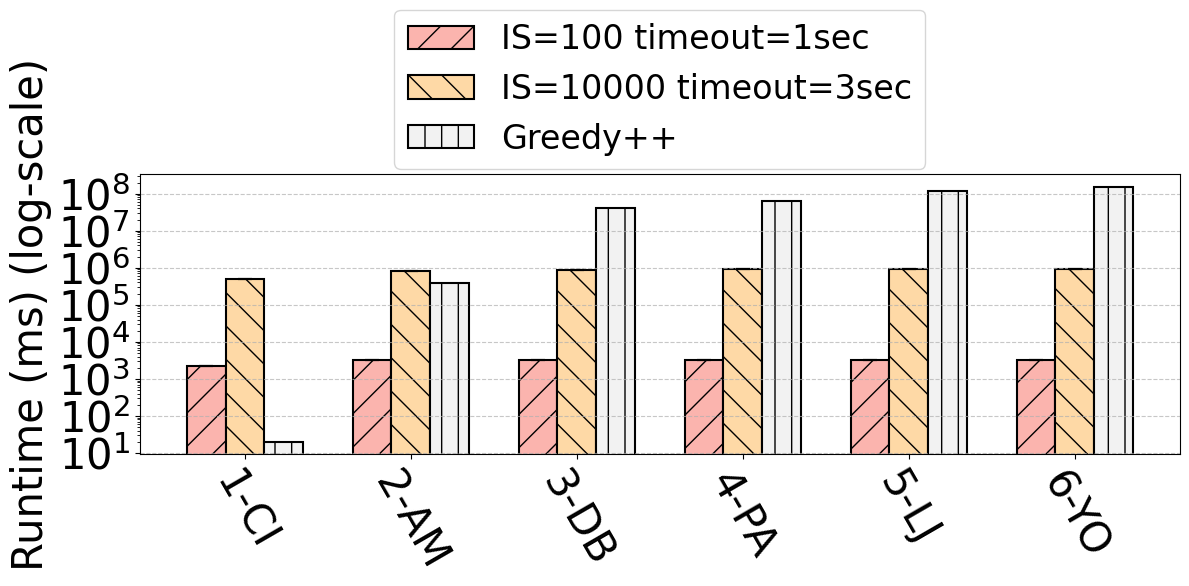

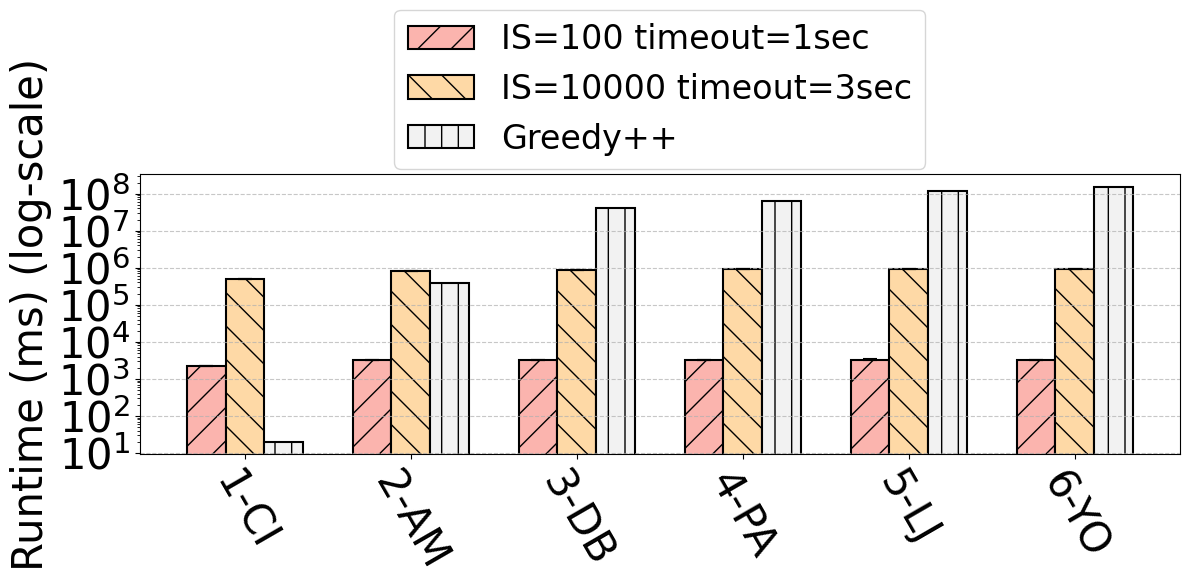

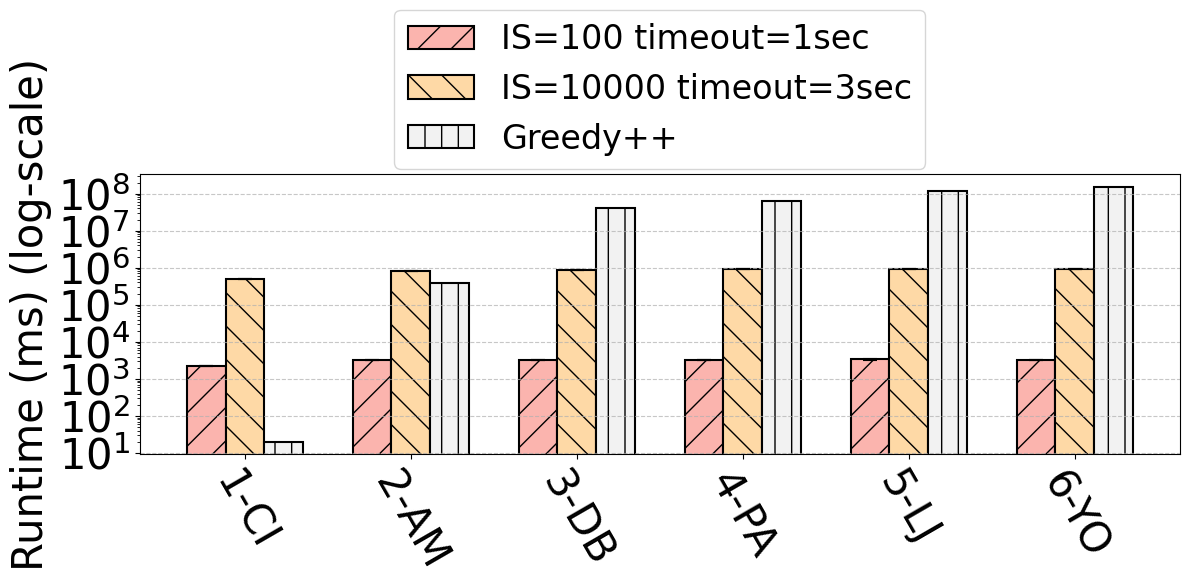

In [38]:
grouping_cols = ["graph_name"]
metaheuristics = ["vns", "ils", "ts1"]

for mh in metaheuristics:
    df = grouped_df[
        (grouped_df["metaheuristic"] == mh) &
        (grouped_df["objective_function"] == "densesubgraph") &
        (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
        ( ((grouped_df['num_initial_solutions'] == 100) & (grouped_df['timeout_ms'] == 1000)) | ((grouped_df['num_initial_solutions'] == 10000) & (grouped_df['timeout_ms'] == 3000)) )
        ].copy().reset_index()
    df['graph_name'] = df['graph_name'].replace({
        'citeseer': '1-CI',
        'amazon': '2-AM',
        'dblp': '3-DB',
        'patents': '4-PA',
        'livejournal': '5-LJ',
        'youtube': '6-YO',
    })
    plot_average_by_group_and_initial_solutions(df, grouping_cols, {'Greedy++': [20.13, 387290.85, 40347219.34, 64566739.03, 117710440.00, 152081432.80]}, title="Runtime " + mh.upper() + " Dense Subgraph", log_scale=True, metaheuristic=mh, obj_function="densesubgraph")

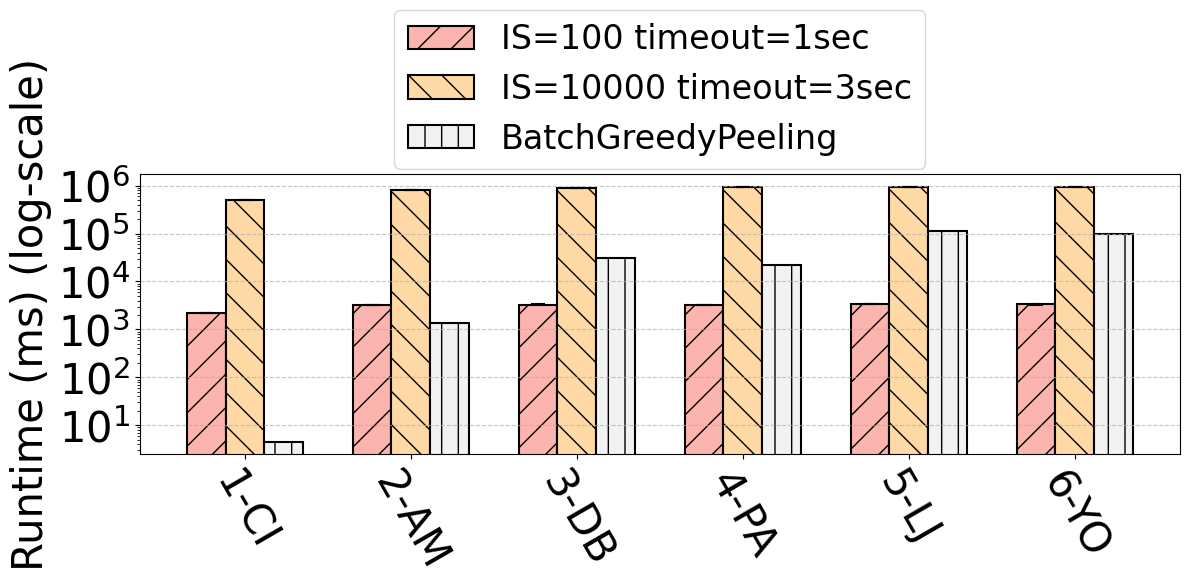

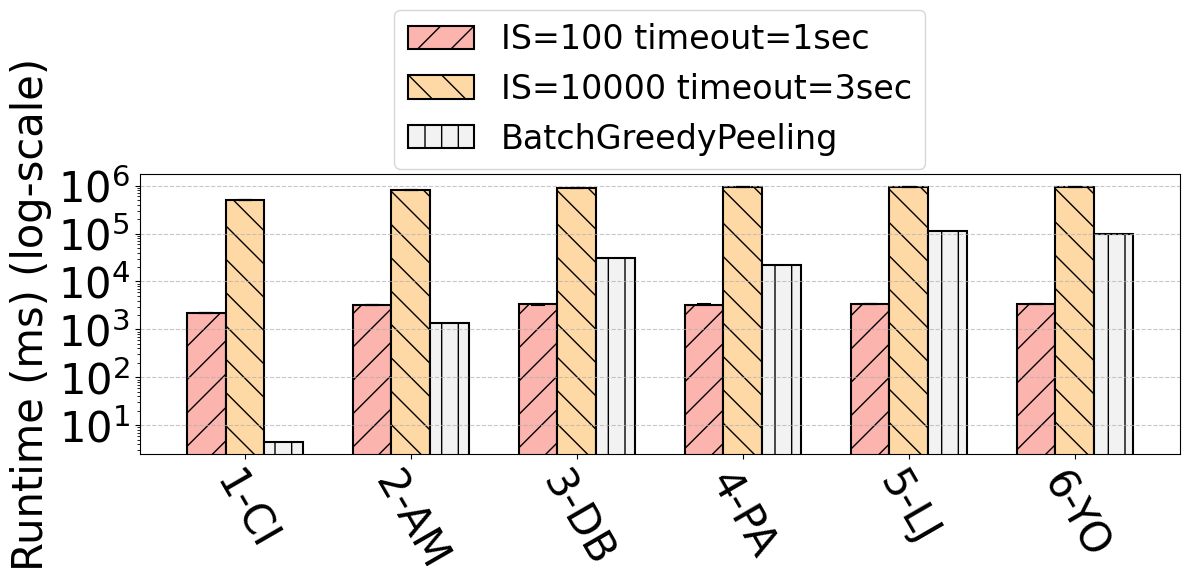

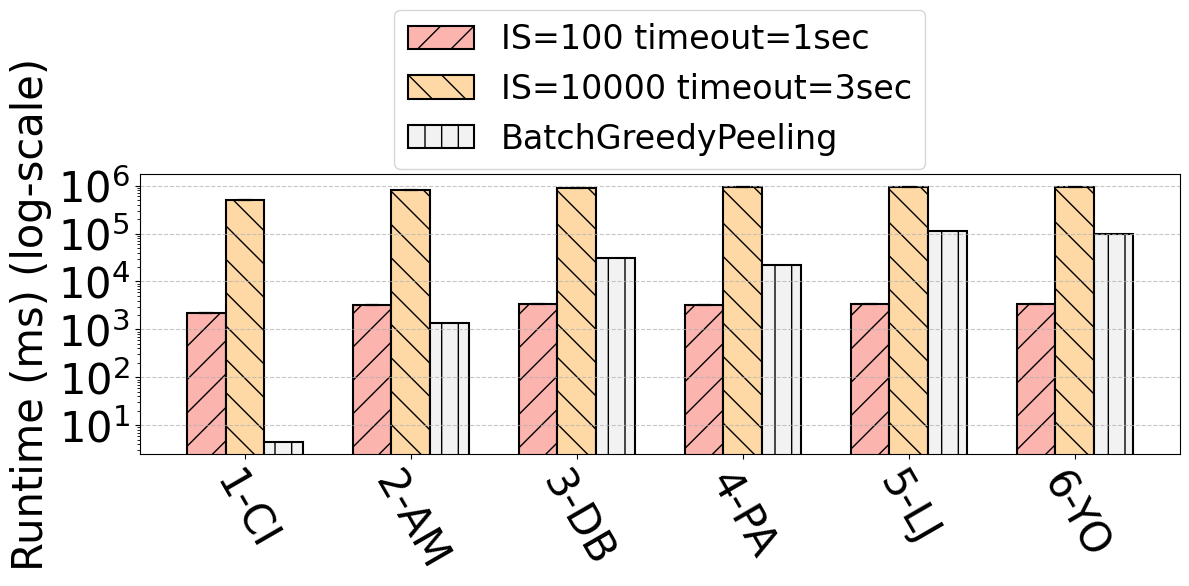

In [39]:
grouping_cols = ["graph_name"]
metaheuristics = ["vns", "ils", "ts1"]

for mh in metaheuristics:

    df = grouped_df[
        (grouped_df["metaheuristic"] == mh) &
        (grouped_df["objective_function"] == "triangledensestsubgraph") &
        (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
        ( ((grouped_df['num_initial_solutions'] == 100) & (grouped_df['timeout_ms'] == 1000)) | ((grouped_df['num_initial_solutions'] == 10000) & (grouped_df['timeout_ms'] == 3000)) )
        ].copy().reset_index()

    df['graph_name'] = df['graph_name'].replace({
        'citeseer': '1-CI',
        'amazon': '2-AM',
        'dblp': '3-DB',
        'patents': '4-PA',
        'livejournal': '5-LJ',
        'youtube': '6-YO',
    })
    plot_average_by_group_and_initial_solutions(df, grouping_cols, {'BatchGreedyPeeling': [4.56, 1348.24, 30277.58, 22165.50, 111821.86, 96434.07]}, title="Runtime " + mh.upper() + " Triangle Densest Subgraph", log_scale=True, metaheuristic=mh, obj_function="triangledensestsubgraph")